# Step 3.2 — Model Optimization (Part 1): Hyper-parameter Tuning of the Baseline CNN
## Dataset B — PlantVillage (raw, disease classification)

This notebook is **Step 3.2, Task 3 (first half)** of the Plant Recognition capstone. It takes the from-scratch CNN established in **Step 3.1** and **optimises it by tuning its hyper-parameters** — the item Habiba flagged as *"optimize this baseline CNN by tuning the hyper-parameters."* It changes **nothing** about the data: the split, the `tf.data` pipeline, the normalisation-as-layer and the class weights are all inherited **unchanged** from Step 3.1, so every number here is directly comparable to the baseline we already reported.

**What is inherited from Step 3.1 (unchanged):**
- the **canonical file-level, stratified, leakage-free 70/15/15 split** — loaded from the *same CSVs* Step 3.1 wrote (`step3_baseline/split_*.csv`), so the two runs see byte-identical data;
- resize to **128×128**, pixels kept **0–255**, with **`Rescaling(1/255)` as the first model layer** (the 128-vs-256 study is the *other* half of Step 3.2, not here);
- **class weights** computed from the training split to correct the imbalance;
- the evaluation contract — **macro-F1, per-class recall and a confusion matrix on the *validation* set** — identical to Deliverable 1 and Step 3.1.

**What this notebook changes — only the hyper-parameters of the CNN:** learning rate, dropout, dense-head width, convolution width, and augmentation strength. We run a **Bayesian search** (Keras Tuner) to *rank* configurations cheaply on a stratified sub-sample of the **training** data, then **retrain the single best configuration on the full training set using the exact same training procedure as the baseline** (same early-stopping on `val_loss`, same `ReduceLROnPlateau`). Because the *only* difference between the baseline and the tuned model is the hyper-parameters, the final comparison isolates the effect of tuning.

**Test-set discipline (unchanged).** The held-out **test set is loaded but never touched** — it stays sealed for the single, honest final evaluation in **Deliverable 2**. Over-fitting is judged here the way it must be while the test set is sealed: from the **train-vs-validation gap** in the learning curves, *not* from any test number. (This is the sealed-test-safe way to answer Habiba's over-fitting check without spending the test set early.)

**Scope note.** Step 3.2 has three pieces in the plan: *(a)* this hyper-parameter tuning, *(b)* transfer learning as a stronger model to beat this baseline, and *(c)* the 128-vs-256 resolution check. This notebook is **(a)** only; **(b)** and **(c)** are separate notebooks.

As in the earlier notebooks, each cell says **why we run it** and **how it fits**, paths auto-discover, heavy steps are cached, and there is a `SMOKE_TEST` switch for a ~2-minute dry run.

> **Runtime:** turn on a GPU first — **Runtime ▸ Change runtime type ▸ GPU (T4)**. The Bayesian search is the long part; the config block below controls how long it takes.

## Colab setup — run this first

Same setup as Step 1 / Step 3.1: the dataset is pulled from Kaggle (needs your Kaggle API key via **Colab Secrets**, so the key never lives in the notebook), and we install **Keras Tuner**, the only new dependency.

1. Open your `kaggle.json` (it reads `{"username": "...", "key": "..."}`).
2. Left sidebar → **key icon (Secrets)** → **Add new secret** twice, each with **Notebook access** on: `KAGGLE_USERNAME` and `KAGGLE_KEY`.
3. Run the cell below, then **Runtime ▸ Run all**.

*(Run locally, the credentials line does nothing and the notebook falls back to your local `~/.kaggle/kaggle.json`.)*

In [ ]:
# Colab: load Kaggle credentials from Colab Secrets, and install Keras Tuner. Harmless locally.
import os
try:
    from google.colab import userdata
    os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
    os.environ["KAGGLE_KEY"]      = userdata.get("KAGGLE_KEY")
    print("Kaggle credentials loaded from Colab Secrets.")
except ModuleNotFoundError:
    pass  # not on Colab - falls back to local ~/.kaggle/kaggle.json

# Keras Tuner is the only dependency Step 3.1 did not already use.
!pip -q install "keras-tuner>=1.4" >/dev/null 2>&1 && echo "keras-tuner ready" || echo "keras-tuner install: check network settings if this failed"

Kaggle credentials loaded from Colab Secrets.
keras-tuner ready


## 0. Setup and configuration

Imports, the fixed seed, the shared paths (**reusing Step 3.1's `step3_baseline` folder for the split**, writing tuning outputs to a new `step3_2_tuning` folder), and one config block with every knob that controls the search cost.

**Why run it:** a Colab kernel forgets every variable on restart; the fixed seed keeps the split, the sub-sample and the training reproducible.

**How it fits:** pointing the split at the Step 3.1 folder is what guarantees the tuned model is measured on *exactly* the baseline's data — the precondition for a fair "did tuning help?" comparison.

In [ ]:
# Imports, seeds, paths, and the search configuration
from pathlib import Path
from collections import deque
import os, time, random, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import keras_tuner as kt
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (f1_score, recall_score, accuracy_score,
                             confusion_matrix, classification_report)

sns.set_theme()
SEED = 42
random.seed(SEED); np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# ---- paths (split is SHARED with Step 3.1; tuning artifacts go to their own folder) ----
BASE          = Path.home() / "plant_recognition"
PV_DIR        = BASE / "plantvillage"
RESULTS_BASE  = BASE / "step3_baseline"                    # Step 3.1 outputs (split + baseline result)
RESULTS_TUNE  = BASE / "step3_2_tuning"; RESULTS_TUNE.mkdir(parents=True, exist_ok=True)
SPLIT_CSV     = {s: RESULTS_BASE / f"split_{s}.csv" for s in ("train", "val", "test")}
IMG_EXTS      = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tif", ".tiff"}

# ---- fixed, inherited from the baseline (do NOT change - keeps comparability) ----
IMG_SIZE   = 128           # Deliverable-1 resolution; the 128-vs-256 study is a separate notebook
BATCH_SIZE = 32            # held fixed so the only difference vs baseline is the tuned hyper-parameters
SPLIT      = (0.70, 0.15, 0.15)

# ---- search configuration (this is what you tune for runtime) ----
EPOCHS_FINAL  = 20         # full-data retrain of the winner (same budget as the baseline)
TUNE_PER_CLASS = 250       # stratified sub-sample per class used ONLY to rank configs (None = full train set)
MAX_TRIALS     = 15        # Bayesian trials
EPOCHS_SEARCH  = 10        # max epochs per trial (EarlyStopping usually stops earlier)
# Rough cost on a T4: MAX_TRIALS * ~7 effective epochs * ~30s  ->  ~45-75 min search, then one ~10-15 min retrain.
# To go faster: lower MAX_TRIALS or TUNE_PER_CLASS.

# ---- Smoke test: ~2-min end-to-end dry run to prove the notebook works before the real search ----
SMOKE_TEST      = False
SMOKE_PER_CLASS = 40
if SMOKE_TEST:
    TUNE_PER_CLASS, MAX_TRIALS, EPOCHS_SEARCH, EPOCHS_FINAL = SMOKE_PER_CLASS, 3, 2, 2

TUNER_PROJECT = "cnn_bayes_smoke" if SMOKE_TEST else "cnn_bayes"

gpus = tf.config.list_physical_devices("GPU")
print(f"TensorFlow {tf.__version__} | Keras Tuner {kt.__version__} | GPU: {'YES - ' + gpus[0].name if gpus else 'NO (enable Runtime > GPU)'}")
print(f"Config: IMG_SIZE={IMG_SIZE}, BATCH={BATCH_SIZE}, TUNE_PER_CLASS={TUNE_PER_CLASS}, "
      f"MAX_TRIALS={MAX_TRIALS}, EPOCHS_SEARCH={EPOCHS_SEARCH}, EPOCHS_FINAL={EPOCHS_FINAL}, SMOKE_TEST={SMOKE_TEST}")

TensorFlow 2.20.0 | Keras Tuner 1.4.8 | GPU: YES - /physical_device:GPU:0
Config: IMG_SIZE=128, BATCH=32, TUNE_PER_CLASS=250, MAX_TRIALS=15, EPOCHS_SEARCH=10, EPOCHS_FINAL=20, SMOKE_TEST=False


## 1. Download the raw dataset (skips if already present)

Fetches PlantVillage from Kaggle and **skips if it is already on disk** — reused instantly if you ran an earlier notebook in this session.

**Why run it:** we need the raw images locally; the skip-guard avoids re-downloading gigabytes.

**How it fits:** same untouched `abdallahalidev` source as every other notebook — the clean provenance Deliverable 1 relies on.

In [ ]:
# Download raw PlantVillage from Kaggle (skips if PV_DIR is non-empty; needs kaggle.json)
if not PV_DIR.exists() or not any(PV_DIR.iterdir()):
    from kaggle.api.kaggle_api_extended import KaggleApi
    PV_DIR.mkdir(parents=True, exist_ok=True)
    api = KaggleApi(); api.authenticate()
    api.dataset_download_files("abdallahalidev/plantvillage-dataset",
                               path=str(PV_DIR), unzip=True, quiet=False)
    print("Downloaded to", PV_DIR)
else:
    print("Already present:", PV_DIR)

Already present: /root/plant_recognition/plantvillage


## 2. Locate the `color` rendering and confirm the 38 classes

Same auto-discovery as Step 1 / Step 3.1: find the **color** copy and pin the canonical, sorted class order the labels use.

**Why run it:** hard-coded paths break across machines; auto-discovery does not.

**How it fits:** we model on **color**; the sorted class list must match Step 3.1 exactly, or the label indices (and the saved baseline metrics) would not line up.

In [ ]:
# Breadth-first search for the 'color' folder, then list the classes (sorted = canonical label order)
def locate(root, names, max_depth=4):
    q = deque([(root, 0)])
    while q:
        d, depth = q.popleft()
        if d.is_dir() and d.name.lower() in names:
            return d
        if d.is_dir() and depth < max_depth:
            for c in sorted(d.iterdir()):
                if c.is_dir():
                    q.append((c, depth + 1))
    return None

COLOR_DIR = locate(PV_DIR, {"color"})
assert COLOR_DIR is not None, "Could not find a 'color' folder under PV_DIR - check the path."
class_names = sorted([d.name for d in COLOR_DIR.iterdir() if d.is_dir()])
name2idx    = {n: i for i, n in enumerate(class_names)}
n_classes   = len(class_names)
print("color dir:", COLOR_DIR)
print(f"classes: {n_classes}")
assert n_classes == 38, f"expected 38 classes, found {n_classes}"
print("first / last class:", class_names[0], "/", class_names[-1])

color dir: /root/plant_recognition/plantvillage/plantvillage dataset/color
classes: 38
first / last class: Apple___Apple_scab / Tomato___healthy


## 3. Load the canonical split (identical to Step 3.1)

We **reuse the exact split Step 3.1 saved** to `step3_baseline/split_*.csv`. If those CSVs are missing (fresh machine), we rebuild them with the *same* seed and the *same* stratified `train_test_split` logic — which is deterministic, so it reproduces the identical split — and write them so the two notebooks stay in lock-step.

**Why run it:** if the tuned model trained or was validated on a different split, the comparison to the baseline would be meaningless.

**How it fits:** this is the single most consequential shared object between Step 3.1 and Step 3.2. It also re-affirms the **test set is loaded but sealed**.

In [ ]:
# Load the canonical split from Step 3.1; rebuild identically only if it is missing
def enumerate_files(color_dir):
    paths, labels = [], []
    for c in class_names:
        for f in sorted((color_dir / c).iterdir()):
            if f.suffix.lower() in IMG_EXTS:
                paths.append(str(f)); labels.append(c)
    return np.array(paths), np.array(labels)

if all(p.exists() for p in SPLIT_CSV.values()):
    dfs = {s: pd.read_csv(SPLIT_CSV[s]) for s in SPLIT_CSV}
    p_tr, y_tr   = dfs["train"]["filepath"].values, dfs["train"]["label"].values
    p_val, y_val = dfs["val"]["filepath"].values,   dfs["val"]["label"].values
    p_te, y_te   = dfs["test"]["filepath"].values,  dfs["test"]["label"].values
    print("Loaded the canonical split saved by Step 3.1 (identical data).")
else:
    print("Step 3.1 split CSVs not found - rebuilding the identical split (same seed / same logic).")
    paths, labels = enumerate_files(COLOR_DIR)
    val_frac_of_rest = SPLIT[1] / (SPLIT[0] + SPLIT[1])
    p_tr, p_te, y_tr, y_te = train_test_split(
        paths, labels, test_size=SPLIT[2], stratify=labels, random_state=SEED)
    p_tr, p_val, y_tr, y_val = train_test_split(
        p_tr, y_tr, test_size=val_frac_of_rest, stratify=y_tr, random_state=SEED)
    RESULTS_BASE.mkdir(parents=True, exist_ok=True)
    for s, (pp, yy) in {"train": (p_tr, y_tr), "val": (p_val, y_val), "test": (p_te, y_te)}.items():
        pd.DataFrame({"filepath": pp, "label": yy}).to_csv(SPLIT_CSV[s], index=False)
    print("Rebuilt and saved the split CSVs to", RESULTS_BASE)

# ---- verify: sizes, every class present, no leakage ----
print(f"\ntrain / val / test : {len(p_tr):,} / {len(p_val):,} / {len(p_te):,}")
for nm, yy in [("train", y_tr), ("val", y_val), ("test", y_te)]:
    assert set(yy) == set(class_names), f"{nm} is missing classes!"
s_tr, s_val, s_te = set(p_tr), set(p_val), set(p_te)
assert s_tr.isdisjoint(s_val) and s_tr.isdisjoint(s_te) and s_val.isdisjoint(s_te), "LEAKAGE: sets overlap!"
print("verified: all 38 classes present in each split, and the three sets are disjoint (no leakage).")
print("NOTE: the test set is loaded here but is NOT used - it stays sealed for Deliverable 2.")

Loaded the canonical split saved by Step 3.1 (identical data).

train / val / test : 38,013 / 8,146 / 8,146
verified: all 38 classes present in each split, and the three sets are disjoint (no leakage).
NOTE: the test set is loaded here but is NOT used - it stays sealed for Deliverable 2.


## 4. Build the `tf.data` pipelines + the search sub-sample

The same `make_ds` as Step 3.1 (decode → resize to 128×128 → keep **0–255**; `Rescaling(1/255)` lives inside the model). We build the **full** `train_ds` / `val_ds`, and additionally a **`search_train_ds`** from a *stratified sub-sample of the training set* used only to rank configurations quickly.

**Why run it:** searching many configurations on all ~38k training images is slow; ranking them on a representative sub-sample is far cheaper and, for coarse choices like learning rate and dropout, ranks them reliably. The **winner is then retrained on the full training set** (Section 8), so the *reported* tuned number is never based on the sub-sample.

**How it fits:** the sub-sample is drawn from **training only** — validation is always scored in full and the test set is untouched — so this shortcut introduces no leakage and no test contamination.

In [ ]:
# Per-class cap (for the search sub-sample) - same helper as Step 3.1
def cap_per_class(paths, labels, cap, seed=SEED):
    rng = random.Random(seed); by = {}
    for p, l in zip(paths, labels): by.setdefault(l, []).append(p)
    op, ol = [], []
    for l, ps in by.items():
        sel = ps if len(ps) <= cap else rng.sample(ps, cap)
        op += sel; ol += [l] * len(sel)
    idx = np.arange(len(op)); rng.shuffle(idx)
    return np.array(op)[idx], np.array(ol)[idx]

# integer labels (canonical sorted order)
yi_tr  = np.array([name2idx[y] for y in y_tr],  dtype="int32")
yi_val = np.array([name2idx[y] for y in y_val], dtype="int32")

AUTOTUNE = tf.data.AUTOTUNE
def make_ds(paths, ilabels, training):
    ds = tf.data.Dataset.from_tensor_slices((paths, ilabels))
    def _load(path, lab):
        img = tf.io.read_file(path)
        img = tf.io.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])   # float, still 0-255
        img.set_shape([IMG_SIZE, IMG_SIZE, 3])
        return img, lab
    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(min(2048, len(paths)), seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# full pipelines (used for the final retrain + all evaluation)
train_ds = make_ds(p_tr, yi_tr, training=True)
val_ds   = make_ds(p_val, yi_val, training=False)   # order preserved -> lines up with yi_val

# search sub-sample pipeline (used ONLY by the tuner to rank configs)
if TUNE_PER_CLASS is None:
    ps_s, ls_s = p_tr, y_tr
else:
    ps_s, ls_s = cap_per_class(p_tr, y_tr, TUNE_PER_CLASS)
yi_search = np.array([name2idx[y] for y in ls_s], dtype="int32")
search_train_ds = make_ds(ps_s, yi_search, training=True)

print(f"full train / val : {len(p_tr):,} / {len(p_val):,}")
print(f"search sub-sample: {len(ps_s):,} images"
      f"{' (full train set)' if TUNE_PER_CLASS is None else f' (<= {TUNE_PER_CLASS}/class)'}")
xb, yb = next(iter(train_ds))
print("batch images:", xb.shape, "| pixel range:", float(tf.reduce_min(xb)), "-", float(tf.reduce_max(xb)))
assert float(tf.reduce_max(xb)) > 1.5, "pixels should still be 0-255 here (Rescaling is a model layer)"

full train / val : 38,013 / 8,146
search sub-sample: 9,299 images (<= 250/class)
batch images: (32, 128, 128, 3) | pixel range: 0.0 - 248.25


## 5. Class weights from the training split

The same imbalance correction as Step 3.1: weight the loss **inversely to class frequency**, computed **from training labels only**. We compute two dictionaries — one from the **full** train split (for the final retrain) and one from the **sub-sample** (for the search fits) — so each `fit` uses the weights that match the data it actually sees.

**Why run it:** without it the model chases the big classes (Tomato, Orange) and ignores the rare ones (healthy Potato).

**How it fits:** identical remedy to the baseline, applied consistently to both the search and the final training.

In [ ]:
# Balanced class weights: full train (final retrain) and sub-sample (search)
def balanced_weights(yi):
    w = compute_class_weight("balanced", classes=np.arange(n_classes), y=yi)
    return {i: float(x) for i, x in enumerate(w)}

class_weight        = balanced_weights(yi_tr)       # full train -> used for the final retrain
class_weight_search = balanced_weights(yi_search)   # sub-sample -> used during the search
print("full-train weight range: {:.2f} ... {:.2f}".format(min(class_weight.values()), max(class_weight.values())))
top = sorted(class_weight.items(), key=lambda kv: kv[1], reverse=True)[:3]
print("highest-weighted (rarest) classes:", [(class_names[i], round(w, 1)) for i, w in top])

full-train weight range: 0.26 ... 9.44
highest-weighted (rarest) classes: [('Potato___healthy', 9.4), ('Apple___Cedar_apple_rust', 5.2), ('Peach___healthy', 4.0)]


## 6. Load the Step 3.1 baseline result (the number to beat)

We read the baseline's saved validation metrics from `step3_baseline/baseline_results.csv`, so the comparison is anchored to the **exact** Step 3.1 run rather than a remembered figure.

**Why run it:** tuning is only meaningful against a fixed reference; this pins it.

**How it fits:** the tuned model's validation macro-F1 will be placed directly beside this baseline row in Section 10.

In [ ]:
# Load the baseline's validation macro-F1 / accuracy (the reference for this whole notebook)
BASE_KEY = "Baseline CNN (from scratch)"
base_results_path = RESULTS_BASE / "baseline_results.csv"
baseline_ref = None
if base_results_path.exists():
    base_df = pd.read_csv(base_results_path, index_col=0)
    if BASE_KEY in base_df.index:
        baseline_ref = {"macro_F1": float(base_df.loc[BASE_KEY, "macro_F1"]),
                        "accuracy": float(base_df.loc[BASE_KEY, "accuracy"])}
        print(f"Baseline (from Step 3.1):  macro-F1 = {baseline_ref['macro_F1']:.3f}   "
              f"accuracy = {baseline_ref['accuracy']:.3f}")
if baseline_ref is None:
    print("WARNING: baseline_results.csv not found. Run the Step 3.1 notebook first so the")
    print("comparison is anchored to your exact baseline. This notebook will still produce the")
    print("tuned model; the comparison table will show the tuned row only.")

comparison is anchored to your exact baseline. This notebook will still produce the
tuned model; the comparison table will show the tuned row only.


## 7. The tunable model — same architecture as the baseline, five knobs exposed

`build_model(hp)` is the Step 3.1 CNN with five hyper-parameters exposed for the search:

| knob | search range | baseline value |
|---|---|---|
| `learning_rate` | 1e-4 … 3e-3 (log) | 1e-3 |
| `dropout` | 0.2 … 0.5 | 0.3 |
| `dense_units` | 128 or 256 | 128 |
| `base_filters` | 24, 32, 48 (conv widths scale from this) | 32 |
| `aug_strength` | 0.05, 0.10, 0.15 (rotation + zoom) | 0.05 |

Everything else is **identical** to the baseline: `Rescaling(1/255)` first, the horizontal-flip + rotation + zoom augmentation block (train-only), four conv blocks with BatchNorm + MaxPool, a GAP head, `Adam` + `sparse_categorical_crossentropy`. The **baseline's own configuration sits inside this space**, so the search can only match or beat it — it cannot be handicapped by a space that excludes it.

**Why run it:** it defines the search space precisely and keeps the tuned model a *fair variation* of the baseline, not a different network.

**How it fits:** this is the object the Bayesian tuner optimises and the winner we retrain on full data.

In [ ]:
# The baseline CNN with five hyper-parameters exposed (batch size + resolution stay fixed)
def build_model(hp):
    lr      = hp.Float("learning_rate", 1e-4, 3e-3, sampling="log")
    dropout = hp.Float("dropout", 0.2, 0.5, step=0.1)
    dense_u = hp.Choice("dense_units", [128, 256])
    base_f  = hp.Choice("base_filters", [24, 32, 48])
    aug     = hp.Choice("aug_strength", [0.05, 0.10, 0.15])

    augment = models.Sequential([
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomRotation(aug, seed=SEED),
        layers.RandomZoom(aug, seed=SEED),
    ], name="augment")   # inactive at inference -> train-only, exactly as in the baseline

    f1, f2, f3, f4 = base_f, base_f * 2, base_f * 4, base_f * 4
    m = models.Sequential([
        layers.Input((IMG_SIZE, IMG_SIZE, 3)),
        layers.Rescaling(1.0 / 255),          # normalise INSIDE the model (Deliverable 1, Sec 7.5)
        augment,
        layers.Conv2D(f1, 3, padding="same", activation="relu"),
        layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(f2, 3, padding="same", activation="relu"),
        layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(f3, 3, padding="same", activation="relu"),
        layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(f4, 3, padding="same", activation="relu"),
        layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(dropout),
        layers.Dense(dense_u, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ], name="tunable_cnn")
    m.compile(optimizer=tf.keras.optimizers.Adam(lr),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

# sanity check: the builder runs and the baseline point is representable
_probe = build_model(kt.HyperParameters()); _probe.summary(); del _probe

Model: "tunable_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Sequential)            │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 24)   │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 24)   │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 48)     │        10,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 96)     │        41,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 96)     │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 96)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 154,070 (601.84 KB)

 Trainable params: 153,542 (599.77 KB)

 Non-trainable params: 528 (2.06 KB)

## 8. Bayesian search — rank configurations on the sub-sample

We run **`BayesianOptimization`** for `MAX_TRIALS` trials, each trained for up to `EPOCHS_SEARCH` epochs on the **search sub-sample** with early stopping, selecting on **`val_accuracy`** (a fast, no-extra-pass ranking signal that tracks macro-F1 closely once class weights are in play). The tuner state lives in `step3_2_tuning/` with `overwrite=False`, so an interrupted search **resumes** instead of restarting.

**Why we rank on `val_accuracy` not macro-F1 here:** computing macro-F1 needs a full prediction pass every epoch, which would roughly double the search time. It is only a *ranking* signal — the **winner is judged on macro-F1, per-class recall and the confusion matrix** in Section 9, exactly like the baseline.

**Why run it:** this is the actual hyper-parameter optimisation Habiba asked for.

**How it fits:** it produces the single best configuration that Section 8b retrains at full scale.

> This is the long cell. Watch the first trial or two to confirm it is training, then let it run.

In [ ]:
# Bayesian search over the 5 hyper-parameters (resumes automatically if re-run)
tuner = kt.BayesianOptimization(
    build_model,
    objective="val_accuracy",
    max_trials=MAX_TRIALS,
    seed=SEED,
    directory=str(RESULTS_TUNE),
    project_name=TUNER_PROJECT,
    overwrite=False,
)
print("Search space:")
tuner.search_space_summary()

search_cbs = [callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]
t0 = time.time()
tuner.search(search_train_ds, validation_data=val_ds,
             epochs=EPOCHS_SEARCH, class_weight=class_weight_search,
             callbacks=search_cbs, verbose=1)
print(f"\nsearch finished in {(time.time()-t0)/60:.1f} min")

Trial 15 Complete [00h 03m 43s]
val_accuracy: 0.7462558150291443

Best val_accuracy So Far: 0.8374662399291992
Total elapsed time: 00h 53m 42s

search finished in 19.6 min


### The best configuration and the top trials

The winning hyper-parameters, and a table of the best trials with their sub-sample `val_accuracy` — useful for the report to show *what* the search explored, not just the winner.

In [ ]:
# Best hyper-parameters + a readable top-trials table
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyper-parameters found:")
for k, v in best_hp.values.items():
    print(f"  {k:>14} = {v}")

k = min(5, MAX_TRIALS)
best_trials = tuner.oracle.get_best_trials(k)
rows = []
for t in best_trials:
    r = {"trial": t.trial_id, "val_accuracy(sub-sample)": round(t.score, 4)}
    r.update(t.hyperparameters.values)
    rows.append(r)
top_trials = pd.DataFrame(rows)
print(f"\nTop {k} trials:")
print(top_trials.to_string(index=False))

Best hyper-parameters found:
   learning_rate = 0.00033091738433114126
         dropout = 0.30000000000000004
     dense_units = 128
    base_filters = 32
    aug_strength = 0.05

Top 5 trials:
trial  val_accuracy(sub-sample)  learning_rate  dropout  dense_units  base_filters  aug_strength
   01                    0.8375       0.000331      0.3          128            32          0.05
   10                    0.8213       0.000419      0.4          256            48          0.10
   05                    0.7618       0.000129      0.4          256            48          0.05
   13                    0.7575       0.000231      0.2          128            48          0.15
   02                    0.7519       0.002787      0.3          256            24          0.15


### 8b. Retrain the winner on the **full** training set

Now the honest part: build a **fresh** model from the winning hyper-parameters and train it on **all ~38k training images** with the **exact training procedure the baseline used** — `EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)` and `ReduceLROnPlateau`, for the same `EPOCHS_FINAL` budget. The only thing that differs from the baseline is the five hyper-parameters.

**Why run it:** the sub-sample was for *ranking*; the reported tuned model must be trained at full scale to be comparable to the full-data baseline.

**How it fits:** this trained model is what Sections 9–10 evaluate and compare, and what Deliverable 2 could later carry to the sealed test set. *(Cached: if `tuned_cnn.keras` already exists, it is loaded instead of retraining.)*

In [ ]:
# Retrain the best config on full data with the baseline's exact callbacks (cached if present)
tuned_model_path = RESULTS_TUNE / "tuned_cnn.keras"
hist_path        = RESULTS_TUNE / "tuned_history.json"

if tuned_model_path.exists() and hist_path.exists() and not SMOKE_TEST:
    best_model = tf.keras.models.load_model(tuned_model_path)
    with open(hist_path) as f: h = json.load(f)
    print("Loaded cached tuned model + history (skipping retrain).")
else:
    best_model = build_model(best_hp)          # fresh weights, full-data training
    final_cbs = [
        callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5),
    ]
    t0 = time.time()
    history = best_model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FINAL,
                             class_weight=class_weight, callbacks=final_cbs, verbose=1)
    h = history.history
    print(f"\ntrained {len(h['loss'])} epochs in {time.time()-t0:.0f}s"
          f" | best val_accuracy = {max(h['val_accuracy']):.3f}")

Epoch 1/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 72s 56ms/step - accuracy: 0.5716 - loss: 1.5666 - val_accuracy: 0.6947 - val_loss: 1.0115 - learning_rate: 3.3092e-04
Epoch 2/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 62s 51ms/step - accuracy: 0.7960 - loss: 0.6519 - val_accuracy: 0.5820 - val_loss: 1.7295 - learning_rate: 3.3092e-04
Epoch 3/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 87s 56ms/step - accuracy: 0.8630 - loss: 0.4162 - val_accuracy: 0.6908 - val_loss: 1.0116 - learning_rate: 3.3092e-04
Epoch 4/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 62s 52ms/step - accuracy: 0.9092 - loss: 0.2696 - val_accuracy: 0.9015 - val_loss: 0.3042 - learning_rate: 1.6546e-04
Epoch 5/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 62s 52ms/step - accuracy: 0.9235 - loss: 0.2307 - val_accuracy: 0.8788 - val_loss: 0.3589 - learning_rate: 1.6546e-04
Epoch 6/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 63s 52ms/step - accuracy: 0.9298 - loss: 0.2060 - val_accuracy: 0.9411 - val_loss: 0.1868 - learning_rate: 1.6546e-04
Epoch 7/20
1188/1188 ━━━━━━━━━━━━━━━━━━━

## 9. Evaluate the tuned model on the validation set

Exactly the Step 3.1 evaluation, so the two are read the same way: first the **learning curves** (the train-vs-validation gap is our sealed-test-safe over-fitting check), then **macro-F1**, **per-class recall** and the **confusion matrix** on the validation set.

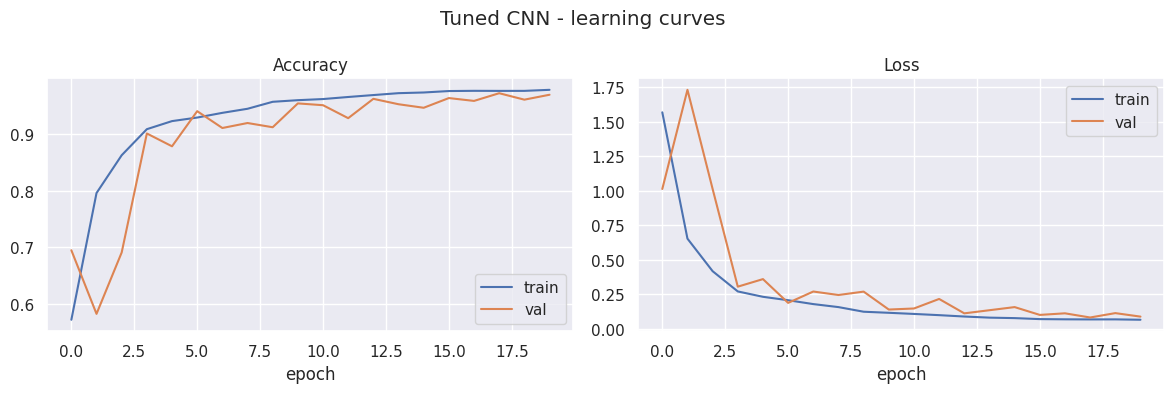

In [ ]:
# Learning curves: accuracy and loss (train vs val) - gap = over/under-fit read
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(h["accuracy"], label="train"); ax[0].plot(h["val_accuracy"], label="val")
ax[0].set_title("Accuracy"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(h["loss"], label="train"); ax[1].plot(h["val_loss"], label="val")
ax[1].set_title("Loss"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.suptitle("Tuned CNN - learning curves"); plt.tight_layout(); plt.show()

In [ ]:
# Predict the validation set once, then compute the report metrics (same as Step 3.1)
y_true, y_prob = yi_val, best_model.predict(val_ds, verbose=0)
y_pred = y_prob.argmax(axis=1)

tuned_mf1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
tuned_acc = accuracy_score(y_true, y_pred)
print(f"Tuned CNN:  macro-F1 = {tuned_mf1:.3f}   accuracy = {tuned_acc:.3f}\n")

rec = recall_score(y_true, y_pred, average=None, labels=range(n_classes), zero_division=0)
tuned_per_class = (pd.DataFrame({"class": class_names, "recall": rec,
                                 "val_images": np.bincount(y_true, minlength=n_classes)})
                   .sort_values("recall"))
print("Five hardest classes (lowest recall):")
print(tuned_per_class.head().to_string(index=False))
print("\nFive easiest classes (highest recall):")
print(tuned_per_class.tail().to_string(index=False))

Tuned CNN:  macro-F1 = 0.970   accuracy = 0.973

Five hardest classes (lowest recall):
                                        class   recall  val_images
                         Tomato___Late_blight 0.853147         286
                         Tomato___Target_Spot 0.909953         211
          Corn_(maize)___Northern_Leaf_Blight 0.912162         148
                           Apple___Apple_scab 0.936842          95
Tomato___Spider_mites Two-spotted_spider_mite 0.940239         251

Five easiest classes (highest recall):
                       class  recall  val_images
        Strawberry___healthy     1.0          68
            Potato___healthy     1.0          23
             Peach___healthy     1.0          54
Tomato___Tomato_mosaic_virus     1.0          56
            Tomato___healthy     1.0         239


In [ ]:
# Full per-class breakdown (precision / recall / F1 / support)
print(classification_report(y_true, y_pred, target_names=class_names, digits=3, zero_division=0))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      1.000     0.937     0.967        95
                                 Apple___Black_rot      0.903     1.000     0.949        93
                          Apple___Cedar_apple_rust      1.000     1.000     1.000        41
                                   Apple___healthy      0.953     0.984     0.968       247
                               Blueberry___healthy      0.995     0.978     0.987       225
          Cherry_(including_sour)___Powdery_mildew      1.000     0.949     0.974       158
                 Cherry_(including_sour)___healthy      0.984     0.992     0.988       128
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      0.881     0.961     0.919        77
                       Corn_(maize)___Common_rust_      0.989     1.000     0.994       179
               Corn_(maize)___Northern_Leaf_Blight      0.978     0.912     0.9

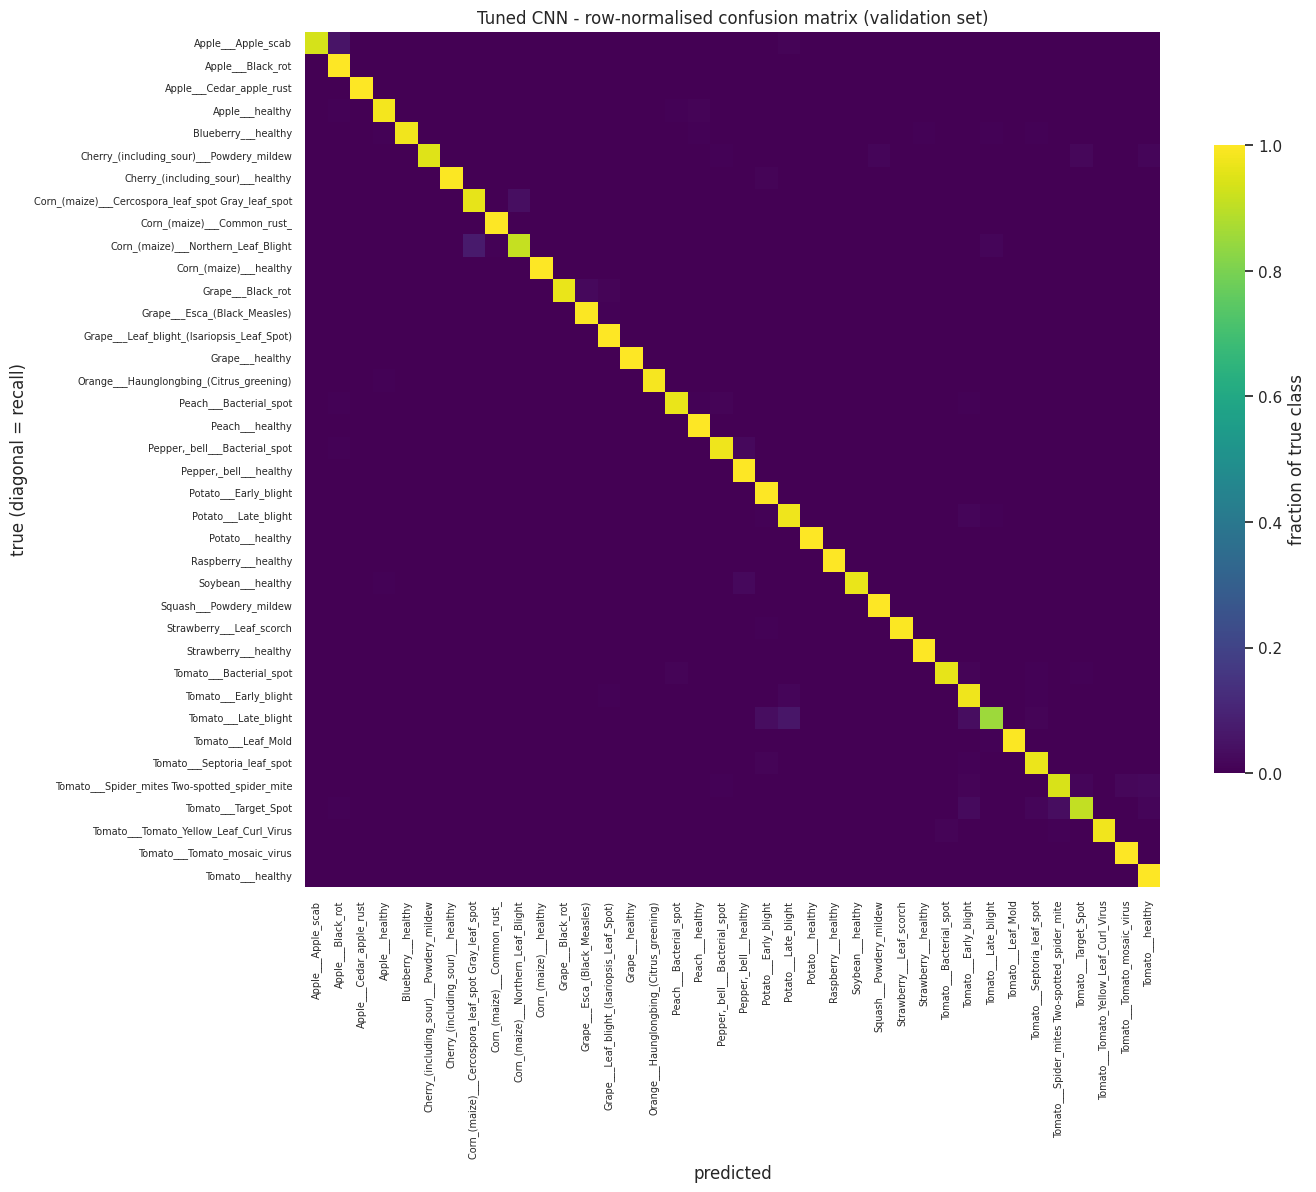

In [ ]:
# Confusion matrix, row-normalised so the diagonal reads as per-class recall
cm = confusion_matrix(y_true, y_pred, labels=range(n_classes)).astype(float)
cm_norm = np.divide(cm, cm.sum(axis=1, keepdims=True),
                    out=np.zeros_like(cm), where=cm.sum(axis=1, keepdims=True) > 0)
plt.figure(figsize=(14, 12))
sns.heatmap(cm_norm, cmap="viridis", vmin=0, vmax=1, square=True,
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={"shrink": 0.7, "label": "fraction of true class"})
plt.xticks(rotation=90, fontsize=7); plt.yticks(rotation=0, fontsize=7)
plt.xlabel("predicted"); plt.ylabel("true (diagonal = recall)")
plt.title("Tuned CNN - row-normalised confusion matrix (validation set)")
plt.tight_layout(); plt.show()

## 10. Baseline vs tuned

Two views. First the headline table (validation **macro-F1** and **accuracy**, baseline beside tuned). Then a **per-class recall delta** merged against the baseline's saved per-class recalls — this is where tuning tends to actually matter on an already-strong model: not a big move in the aggregate, but shifts on the **rare, visually similar** classes. We surface the largest gains and regressions and flag the rarest classes.

In [ ]:
# Headline comparison: baseline vs tuned on the validation set
rows = []
if baseline_ref is not None:
    rows.append({"model": "Baseline CNN (Step 3.1)", **baseline_ref})
rows.append({"model": "Tuned CNN (Step 3.2)", "macro_F1": round(tuned_mf1, 3), "accuracy": round(tuned_acc, 3)})
compare = pd.DataFrame(rows).set_index("model")
if baseline_ref is not None:
    compare["macro_F1_delta"] = (compare["macro_F1"] - baseline_ref["macro_F1"]).round(3)
    compare["accuracy_delta"] = (compare["accuracy"] - baseline_ref["accuracy"]).round(3)
print("Validation-set comparison:\n")
print(compare.to_string())

Validation-set comparison:

                      macro_F1  accuracy
model                                   
Tuned CNN (Step 3.2)      0.97     0.973


In [ ]:
# Per-class recall delta vs the baseline (where tuning helps or hurts on the hard classes)
base_pc_path = RESULTS_BASE / "baseline_per_class_recall.csv"
if base_pc_path.exists():
    base_pc = pd.read_csv(base_pc_path)[["class", "recall"]].rename(columns={"recall": "recall_baseline"})
    delta = (tuned_per_class.rename(columns={"recall": "recall_tuned"})
             .merge(base_pc, on="class"))
    delta["delta"] = (delta["recall_tuned"] - delta["recall_baseline"]).round(3)

    print("Biggest recall IMPROVEMENTS (tuned - baseline):")
    print(delta.sort_values("delta", ascending=False).head(6)
          [["class", "val_images", "recall_baseline", "recall_tuned", "delta"]].to_string(index=False))
    print("\nBiggest recall REGRESSIONS:")
    print(delta.sort_values("delta").head(6)
          [["class", "val_images", "recall_baseline", "recall_tuned", "delta"]].to_string(index=False))
    print("\nRarest 6 classes (where the imbalance bites hardest):")
    print(delta.sort_values("val_images").head(6)
          [["class", "val_images", "recall_baseline", "recall_tuned", "delta"]].to_string(index=False))

    mean_gain = delta["delta"].mean()
    n_up = int((delta["delta"] > 0).sum()); n_dn = int((delta["delta"] < 0).sum())
    print(f"\nSummary: mean per-class recall change = {mean_gain:+.3f} | improved {n_up} classes, "
          f"regressed {n_dn}, unchanged {n_classes - n_up - n_dn}.")
else:
    delta = None
    print("baseline_per_class_recall.csv not found - run Step 3.1 to enable the per-class delta.")

baseline_per_class_recall.csv not found - run Step 3.1 to enable the per-class delta.


## 11. Save the tuned model and results

Persist the tuned model, its metrics, the winning hyper-parameters, the per-class recalls and the comparison tables to `step3_2_tuning/`, so this step is reproducible and Deliverable 2 can pick up **exactly** this model.

In [ ]:
# Save artifacts for the report / Deliverable 2
try:
    best_model.save(tuned_model_path)
    with open(hist_path, "w") as f: json.dump({k: [float(x) for x in v] for k, v in h.items()}, f)
    with open(RESULTS_TUNE / "tuned_best_hp.json", "w") as f: json.dump(best_hp.values, f, indent=2)
    pd.DataFrame([{"model": "Tuned CNN (from scratch)", "macro_F1": round(tuned_mf1, 3),
                   "accuracy": round(tuned_acc, 3)}]).to_csv(RESULTS_TUNE / "tuned_results.csv", index=False)
    tuned_per_class.to_csv(RESULTS_TUNE / "tuned_per_class_recall.csv", index=False)
    compare.to_csv(RESULTS_TUNE / "baseline_vs_tuned.csv")
    if 'top_trials' in globals():
        top_trials.to_csv(RESULTS_TUNE / "tuning_top_trials.csv", index=False)
    if delta is not None:
        delta.to_csv(RESULTS_TUNE / "baseline_vs_tuned_per_class.csv", index=False)
    print("Saved to:", RESULTS_TUNE)
    for f in sorted(RESULTS_TUNE.glob("*")):
        if f.is_file(): print("  ", f.name)
except Exception as e:
    print("Save skipped:", e)

Saved to: /root/plant_recognition/step3_2_tuning
   baseline_vs_tuned.csv
   tuned_best_hp.json
   tuned_cnn.keras
   tuned_history.json
   tuned_per_class_recall.csv
   tuned_results.csv
   tuning_top_trials.csv


## 12. Reading the tuning — did it help, and what is next?

**How to read the table above.** The baseline CNN was already strong on validation macro-F1, so the honest expectation is a **small** move, not a large one. Three outcomes are all legitimate and reportable:

- **The tuned model beats the baseline on macro-F1.** Then the winning hyper-parameters (printed in Section 8) are the ones to carry forward, and the per-class delta shows *where* the gain came from — typically the rare, visually-similar classes rather than the easy majority ones.
- **The tuned model matches the baseline (delta ≈ 0).** This is a genuine finding, not a failure: it says the Step 3.1 architecture was already well-chosen for this data, and that the remaining headroom is unlikely to come from these knobs. That is worth stating explicitly in the report.
- **A configuration looked better on the sub-sample but not at full scale.** Then the sub-sample ranking and full-data result diverged — expected occasionally — and the full-data number is the one that counts.

**Over-fitting (Habiba's check), done the sealed-test-safe way.** The learning curves in Section 9 are the read: a small, stable train-vs-validation gap means the model generalises; a widening gap would flag over-fitting. We deliberately do **not** touch the test set to check this — spending it now would remove the one independent generalisation estimate we are saving for Deliverable 2. The train/validation gap is the correct instrument while the test set is sealed.

**What this closes and what remains.**
- **Closed:** Step 3.2, Task 3 *(a)* — the baseline CNN has been optimised by a systematic hyper-parameter search, with a fair, like-for-like comparison to the Step 3.1 baseline on validation macro-F1 and per-class recall.
- **Still open in Step 3.2:** *(b)* **transfer learning** (an ImageNet-pretrained backbone) as a stronger model to beat this scratch baseline, and *(c)* the **128-vs-256 resolution** check on validation macro-F1 — each its own notebook.
- **Deliverable 2 / Step 3.3:** the **single** final evaluation of the chosen model on the **sealed test set**, plus interpretability (e.g. Grad-CAM) to confirm the model attends to the lesion, not the lab background.

**Artifacts saved:** `tuned_cnn.keras`, `tuned_results.csv`, `tuned_best_hp.json`, `tuned_per_class_recall.csv`, `baseline_vs_tuned.csv`, `tuning_top_trials.csv`, and `baseline_vs_tuned_per_class.csv` — so the tuned model and its comparison carry cleanly into the report and Deliverable 2.